In [11]:
#1.IMPORT LIBRARIES
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [12]:
#2.DEFINE DEVICE
# def get_device():
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
#     return device

Using device: cpu


In [13]:
#3.LOAD DATA
def load_data(train_dir, test_dir):

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),

        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    train_dataset = datasets.ImageFolder(train_dir, transform=transform)
    test_dataset = datasets.ImageFolder(test_dir, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    num_classes = len(train_dataset.classes)
    print("Classes:", train_dataset.classes)

    return train_loader, test_loader, num_classes

In [14]:
#4.LOAD VGG MODEL
def load_vgg(device):

    vgg = models.vgg16(pretrained=True).to(device)

    vgg_features = nn.Sequential(
        vgg.features,
        vgg.avgpool
    )

    return vgg_features

In [15]:
#5.FEATURE EXTRACTION
def extract_features(model, loader, device):

    model.eval()
    features, labels_all = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)

            if isinstance(outputs, tuple):
                outputs = outputs[0]

            outputs = outputs.view(outputs.size(0), -1)

            features.append(outputs.cpu())
            labels_all.append(labels)

    return torch.cat(features), torch.cat(labels_all)

In [16]:
#6.CLASSIFIER MODEL
class MLFNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(MLFNN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 1024),
            nn.ReLU(),

            nn.Linear(1024, 256),
            nn.ReLU(),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [17]:
#7.TRAIN FUNCTION (WITH LOSS TRACKING)
def train_model(X_train, y_train, X_test, y_test, num_classes, device):

    dataset = TensorDataset(X_train, y_train)
    loader = DataLoader(dataset, batch_size=32, shuffle=True)

    input_size = X_train.shape[1]
    model = MLFNN(input_size, num_classes).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0005)

    loss_history = []

    for epoch in range(20):
        model.train()
        total_loss = 0

        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            outputs = model(xb)
            loss = criterion(outputs, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        loss_history.append(total_loss)

        # Evaluation
        model.eval()
        with torch.no_grad():
            X_test_d = X_test.to(device)
            y_test_d = y_test.to(device)

            preds = model(X_test_d)
            _, predicted = torch.max(preds, 1)

            acc = (predicted == y_test_d).float().mean().item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}, Accuracy: {acc:.4f}")

    return model, acc, loss_history

In [18]:
#8.CONFUSION MATRIX
def plot_confusion_matrix(model, X_test, y_test, device):

    model.eval()

    with torch.no_grad():
        X_test_d = X_test.to(device)
        y_test_d = y_test.to(device)

        outputs = model(X_test_d)
        _, predicted = torch.max(outputs, 1)

    cm = confusion_matrix(y_test.cpu(), predicted.cpu())
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()

    plt.title("Confusion Matrix - VGG")
    plt.show()

In [19]:
#9.LOSS GRAPH
def plot_loss(loss_history):

    plt.figure()
    plt.plot(loss_history)
    plt.title("Training Loss Curve - VGG")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

Classes: ['n01494475', 'n01514668', 'n01687978', 'n01742172', 'n02077923']


C:\Users\saima\anaconda3\New folder\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\saima\anaconda3\New folder\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Extracting VGG features...

Training with VGG features
Epoch 1, Loss: 21.9305, Accuracy: 0.9671
Epoch 2, Loss: 1.5859, Accuracy: 0.9700
Epoch 3, Loss: 0.3033, Accuracy: 0.9686
Epoch 4, Loss: 0.0208, Accuracy: 0.9714
Epoch 5, Loss: 0.0050, Accuracy: 0.9729
Epoch 6, Loss: 0.0037, Accuracy: 0.9729
Epoch 7, Loss: 0.0029, Accuracy: 0.9743
Epoch 8, Loss: 0.0023, Accuracy: 0.9729
Epoch 9, Loss: 0.0017, Accuracy: 0.9714
Epoch 10, Loss: 0.0012, Accuracy: 0.9714
Epoch 11, Loss: 0.0009, Accuracy: 0.9714
Epoch 12, Loss: 0.0008, Accuracy: 0.9714
Epoch 13, Loss: 0.0006, Accuracy: 0.9714
Epoch 14, Loss: 0.0005, Accuracy: 0.9729
Epoch 15, Loss: 0.0003, Accuracy: 0.9729
Epoch 16, Loss: 0.0003, Accuracy: 0.9743
Epoch 17, Loss: 0.0002, Accuracy: 0.9729
Epoch 18, Loss: 0.0002, Accuracy: 0.9729
Epoch 19, Loss: 0.0001, Accuracy: 0.9743
Epoch 20, Loss: 0.0001, Accuracy: 0.9729


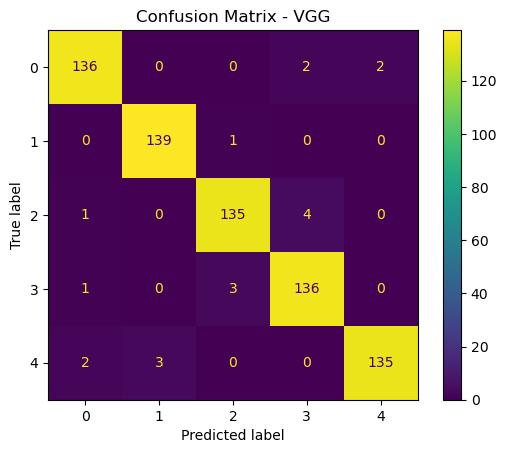

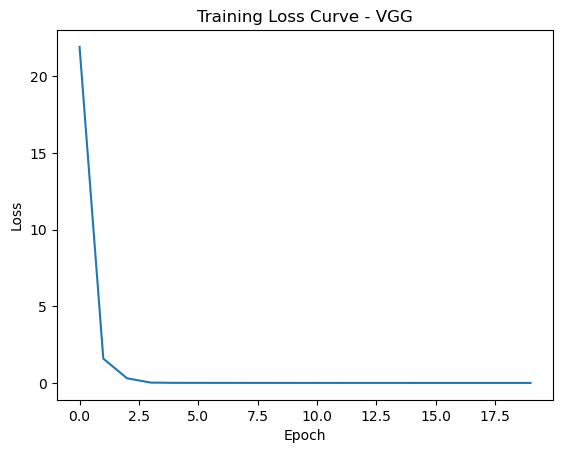


FINAL RESULTS
VGG Accuracy: 97.2857117652893


In [20]:
def main():

#     device = get_device()

    train_dir = r"C:\Users\saima\Desktop\M-Tech\MTech sem 2\DL\Assignments\Assignment 2\DataSets\Image dataset for classification\train"
    test_dir = r"C:\Users\saima\Desktop\M-Tech\MTech sem 2\DL\Assignments\Assignment 2\DataSets\Image dataset for classification\test"

    # Load data
    train_loader, test_loader, num_classes = load_data(train_dir, test_dir)

    # Load VGG
    vgg_features = load_vgg(device)

    # Extract features
    print("\nExtracting VGG features...")
    X_train_vgg, y_train = extract_features(vgg_features, train_loader, device)
    X_test_vgg, y_test = extract_features(vgg_features, test_loader, device)

    # Train model
    print("\nTraining with VGG features")
    model, acc_vgg, loss_history = train_model(
        X_train_vgg, y_train, X_test_vgg, y_test, num_classes, device
    )

    # Confusion Matrix
    plot_confusion_matrix(model, X_test_vgg, y_test, device)

    # Loss Graph
    plot_loss(loss_history)

    # Final Results
    print("\nFINAL RESULTS")
    print("VGG Accuracy:", acc_vgg * 100)

    
if __name__ == "__main__":
    main()